In [2]:
import matplotlib.pyplot as plt

In [3]:
# Quick code to load json files and get stats
import json
import re
def getStats( filename ):
    with open( filename, 'r') as file:
        data = json.load(file)

    X = []
    response50 = []
    response95 = []
    hitrate = []
    throughput = []
    for key in data:
        X.append( key )

        key_data = data[key]
        raw = key_data["raw"]

        # print( raw )
        match = re.search(r'/.*50\.00\% in (\d+\.\d+) secs.*95\.00\% in (\d+\.\d+) secs', raw, flags = re.DOTALL)
        response50.append( float( match.group(1) ) * 1000 )
        response95.append( float( match.group(2) ) * 1000 )

        if( "hit_rate" in key_data ):
            hitrate.append( key_data["hit_rate"] )
        throughput.append( key_data["throughput"] )

    out = {"50": response50, "95":response95,"hit_rate":hitrate,"throughput":throughput}
    return X, out

In [4]:
def plotStats( X, plots, xLabel, yLabel, title, log_scale = False, i = 0, ylim = -1 ):

    for label, plot in plots:
        if( i == 0 ):
            plt.plot(X, plot, label=label )
        else:
            plt.plot(X[:i], plot[:i], label=label)

    if( log_scale ):
        plt.yscale( "log" )
        plt.ylabel( yLabel + " (Log Scaled)" )
    else:
        if( ylim > 0 ):
            plt.ylim(0, ylim)
        plt.ylabel(yLabel)
    plt.grid()
    plt.xlabel(xLabel)
    plt.title(title)
    plt.legend()
    plt.show()
    

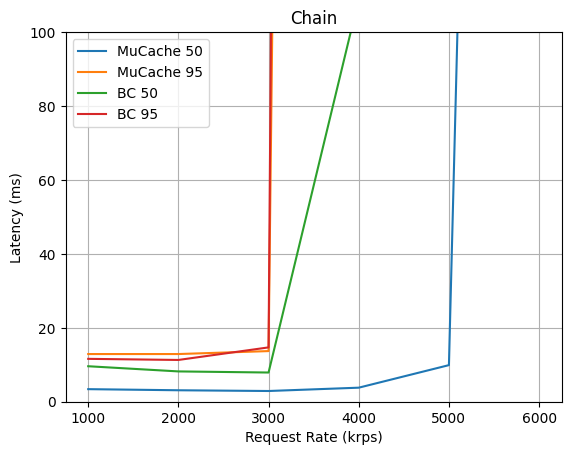

In [14]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
x, bc_out = getStats( "chain-baseline-new.json" )
_, mucache_out = getStats( "chain-new.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, ylim=100 )

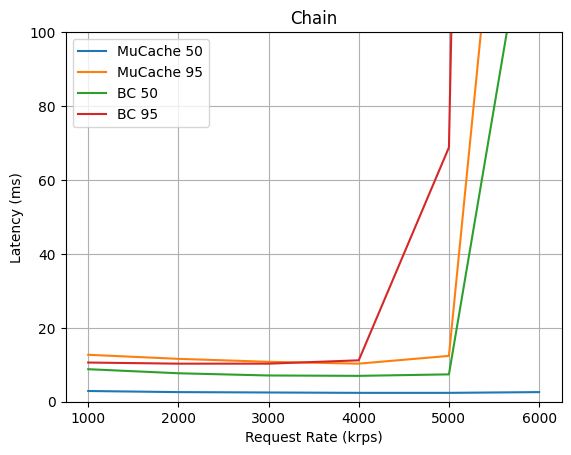

In [51]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
x, bc_out = getStats( "chain-baseline-revert.json" )
_, mucache_out = getStats( "chain-revert.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, ylim=100 )

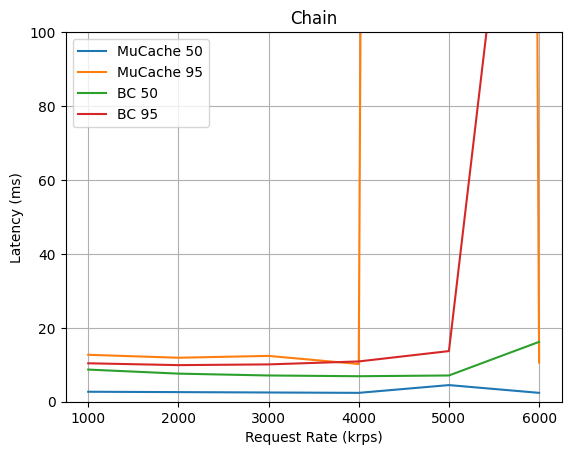

In [18]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
x, bc_out = getStats( "chain-baseline-revert-2.json" )
_, mucache_out = getStats( "chain-revert-2.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, ylim=100 )

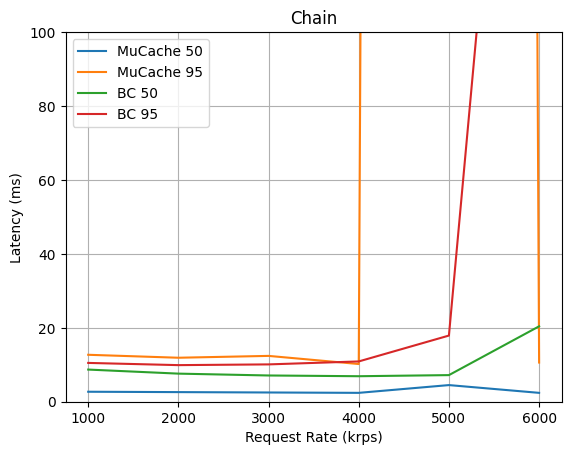

In [19]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
x, bc_out = getStats( "chain-baseline-revert-3.json" )
_, mucache_out = getStats( "chain-revert-2.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, ylim=100 )

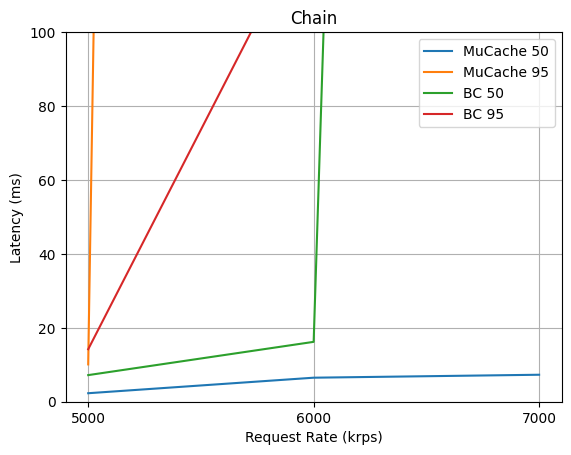

In [22]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
x, bc_out = getStats( "chain-baseline-lower-zmq.json" )
_, mucache_out = getStats( "chain-lower-zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, ylim=100 )

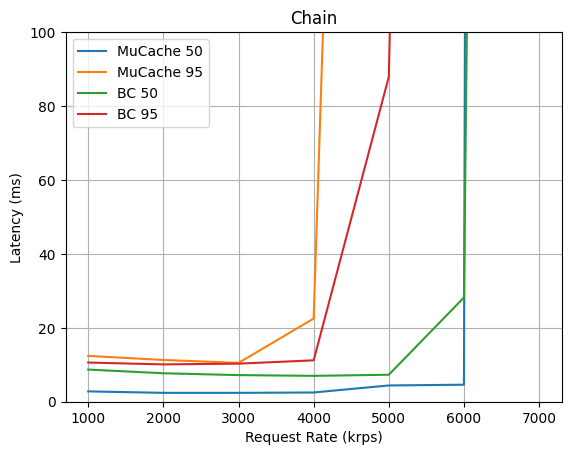

In [26]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
x, bc_out = getStats( "chain-baseline-mem-warmup-2.json" )
_, mucache_out = getStats( "chain-mem-warmup-2.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, ylim=100 )

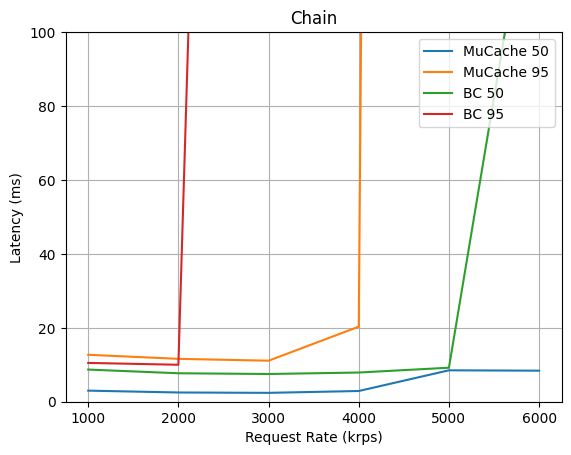

In [27]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
# 1000-1500mi
x, bc_out = getStats( "chain-baseline-lower-app-resources-batch-zmq.json" )
_, mucache_out = getStats( "chain-lower-app-resources-batch-zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, ylim=100 )

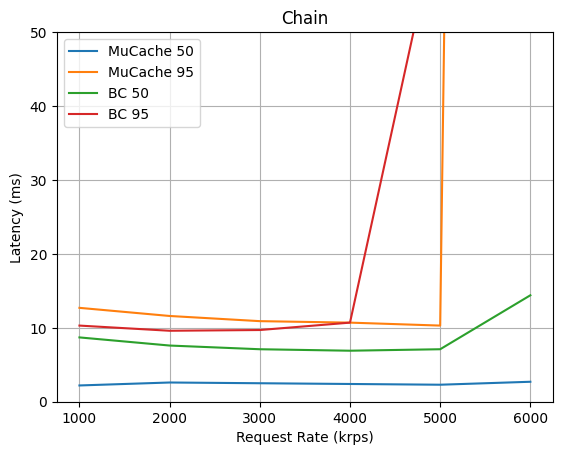

In [63]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
# 1000-1500mi
x, bc_out = getStats( "chain-baseline-batch-zmq-app-cm-resources.json" )
_, mucache_out = getStats( "chain-batch-zmq-app-cm-resources.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, ylim=50 )

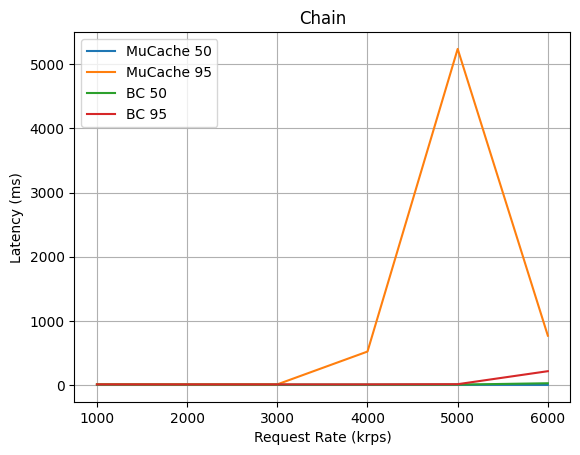

In [77]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
# 1000-1500mi
x, bc_out = getStats( "chain-baseline-recent.json" )
_, mucache_out = getStats( "chain-recent.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, )

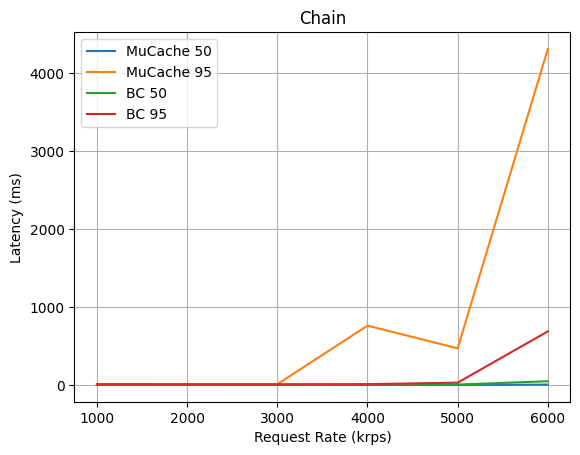

In [78]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
# 1000-1500mi
x, bc_out = getStats( "chain-baseline-recent-2.json" )
_, mucache_out = getStats( "chain-recent-2.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, )

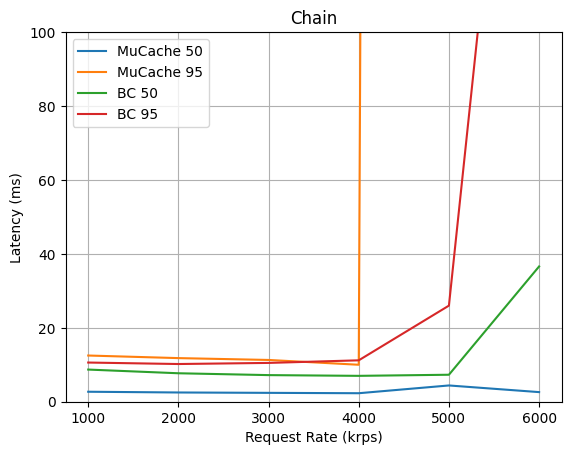

In [82]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
# 1000-1500mi
x, bc_out = getStats( "chain-baseline-1000app.json" )
_, mucache_out = getStats( "chain-1000app.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, ylim = 100 )

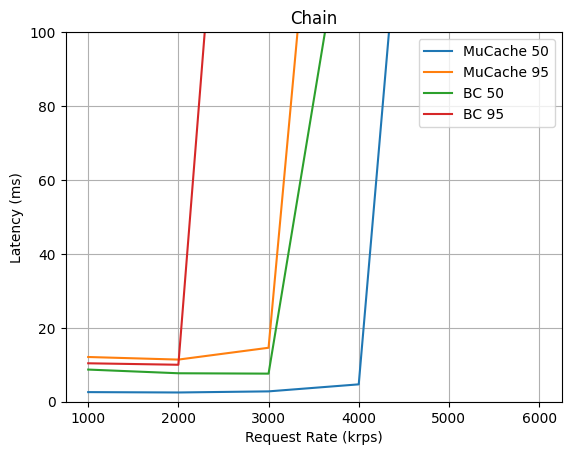

In [83]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
# 1000-1500mi
x, bc_out = getStats( "chain-baseline-1000app-120oha.json" )
_, mucache_out = getStats( "chain-1000app-120oha.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, ylim = 100 )

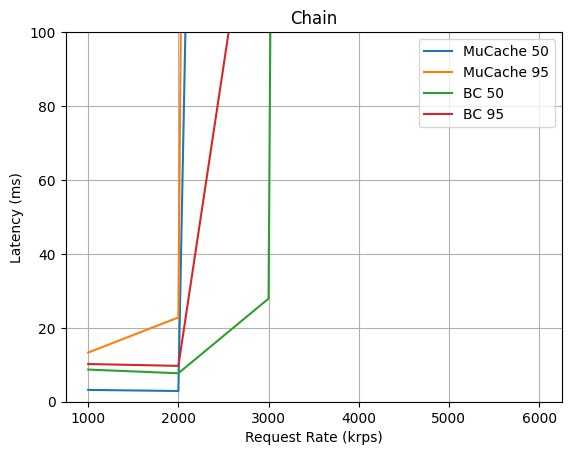

In [102]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
# 1000-1500mi
x, bc_out = getStats( "chain-baseline-proxyworkers12.json" )
_, mucache_out = getStats( "chain-proxyworkers12.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, ylim = 100 )

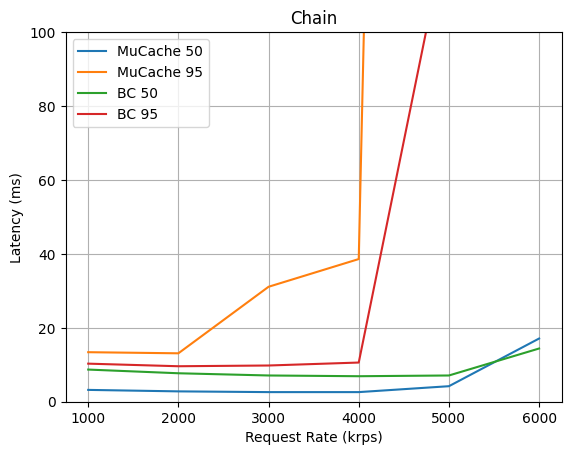

In [103]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
# 1000-1500mi
x, bc_out = getStats( "chain-baseline-proxyworkers12-3000app.json" )
_, mucache_out = getStats( "chain-proxyworkers12-3000app.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, ylim = 100 )

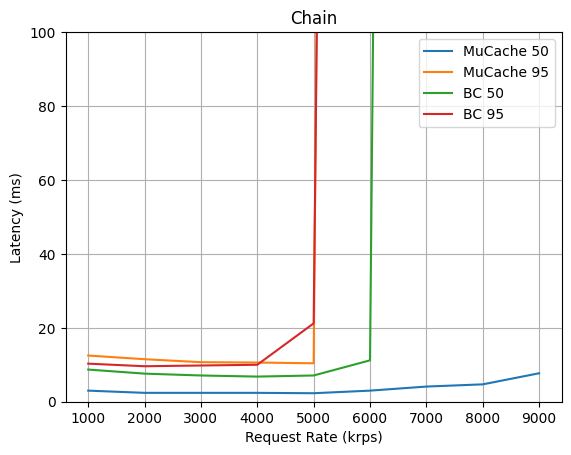

In [134]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
# 1000-1500mi
x, bc_out = getStats( "chain-baseline-5000app-4zmq.json" )
_, mucache_out = getStats( "chain-5000app-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, ylim = 100 )

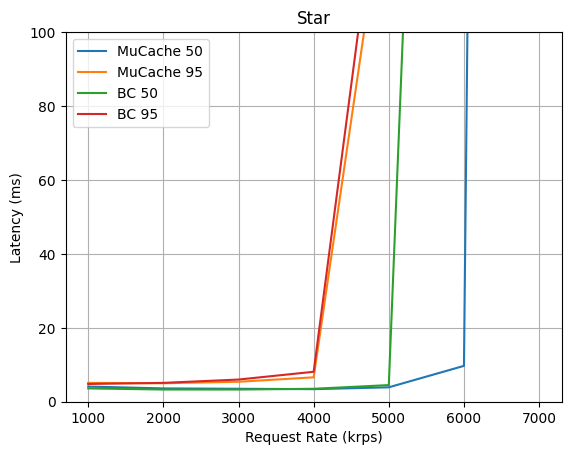

In [136]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
x, bc_out = getStats( "star-baseline-new.json" )
_, mucache_out = getStats( "star-new.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Star", False, ylim = 100 )

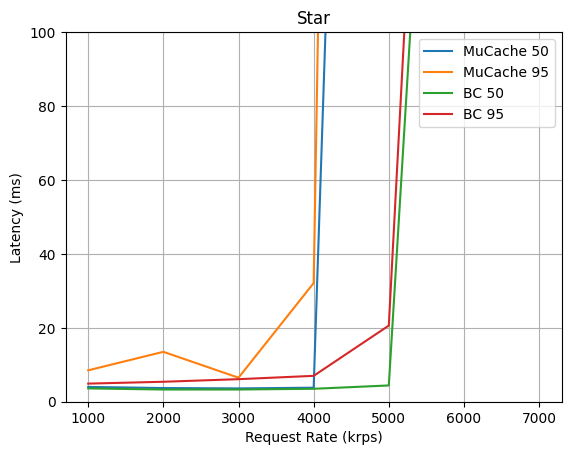

In [17]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
x, bc_out = getStats( "star-baseline-revert-4.json" )
_, mucache_out = getStats( "star-revert-4.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Star", False, ylim = 100 )

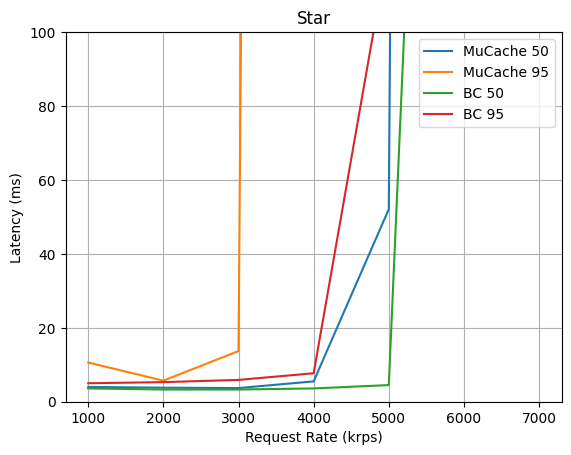

In [29]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
x, bc_out = getStats( "star-baseline-low-app.json" )
_, mucache_out = getStats( "star-low-app.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Star", False, ylim = 100 )

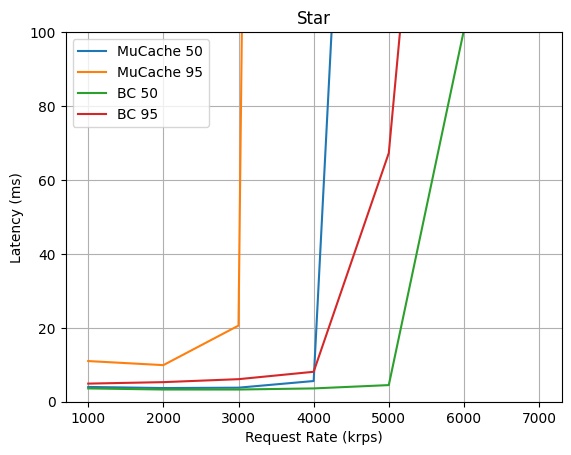

In [30]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
x, bc_out = getStats( "star-baseline-no-app.json" )
_, mucache_out = getStats( "star-no-app.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Star", False, ylim = 100 )

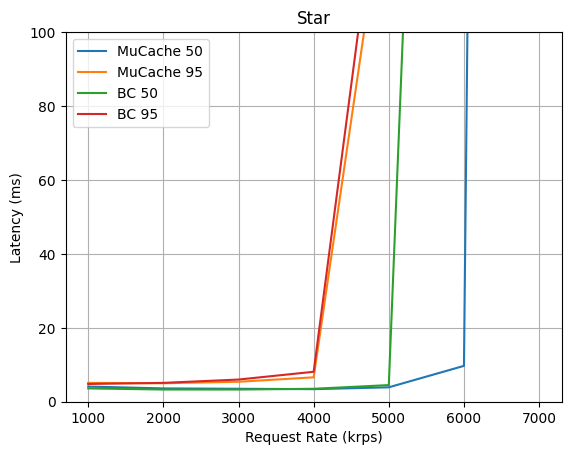

In [130]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
x, bc_out = getStats( "star-baseline-5000app-4zmq.json" )
_, mucache_out = getStats( "star-5000app-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Star", False, ylim = 100 )

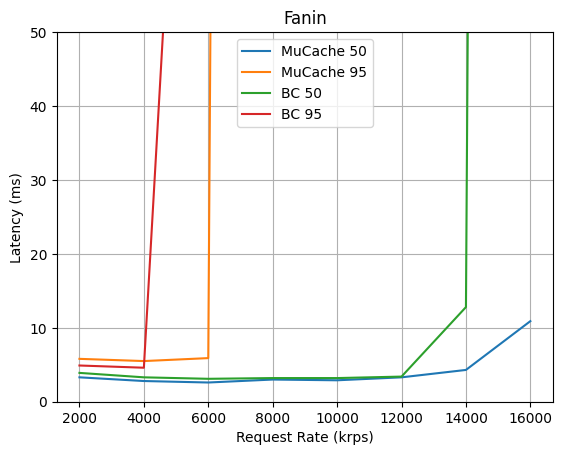

In [20]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
x, bc_out = getStats( "fanin-baseline-new.json" )
_, mucache_out = getStats( "fanin-new.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin", False, ylim = 50 )

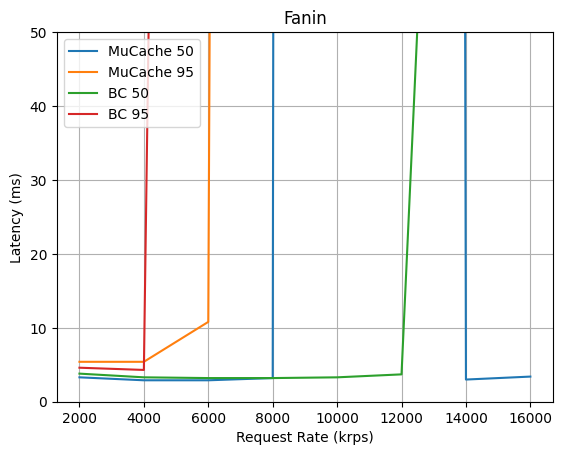

In [31]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
x, bc_out = getStats( "fanin-baseline-500mi.json" )
_, mucache_out = getStats( "fanin-500mi.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin", False, ylim = 50 )

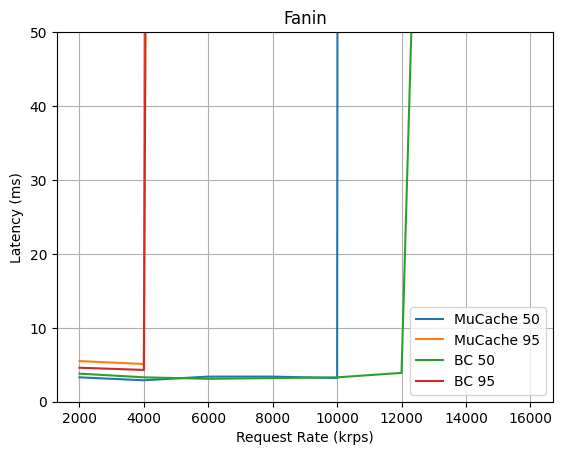

In [32]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
x, bc_out = getStats( "fanin-baseline-1500mi.json" )
_, mucache_out = getStats( "fanin-1500mi.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin", False, ylim = 50 )

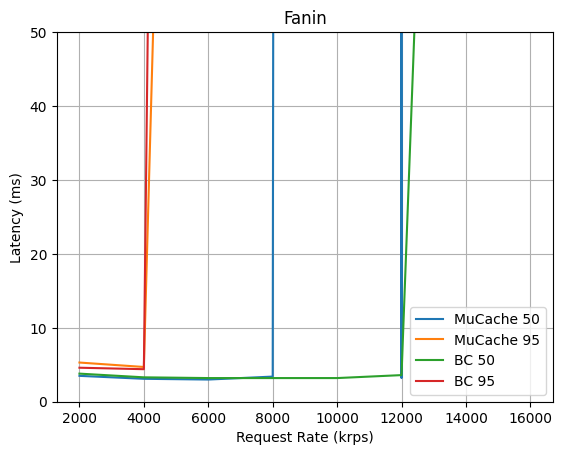

In [36]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
x, bc_out = getStats( "fanin-baseline-1000mi.json" )
_, mucache_out = getStats( "fanin-1000mi.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin", False, ylim = 50 )

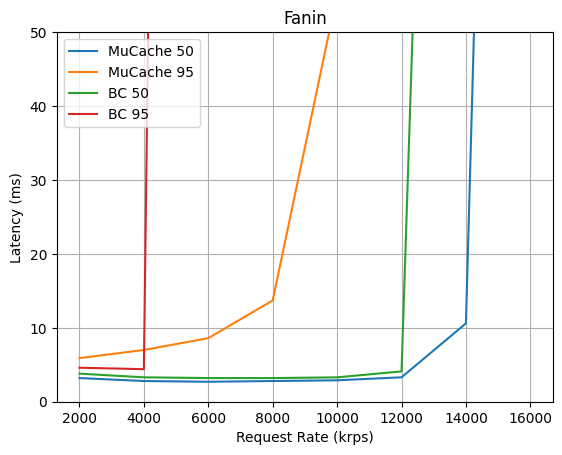

In [35]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
# App 2000mi 2Gi
# Cache 1500mi 2Gi
# Redis 1500mi 2Gi
# CM 2000mi 3Gi
x, bc_out = getStats( "fanin-baseline-even-resources.json" )
_, mucache_out = getStats( "fanin-even-resources.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin", False, ylim = 50 )

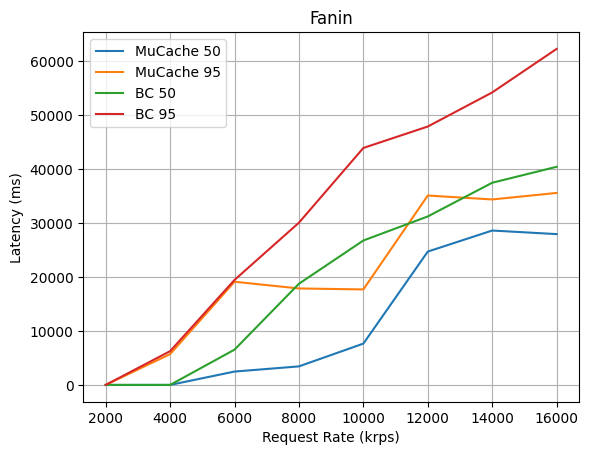

In [87]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
# App 2000mi 2Gi
# Cache 1500mi 2Gi
# Redis 1500mi 2Gi
# CM 2000mi 3Gi
x, bc_out = getStats( "fanin-baseline-1000app-120oha.json" )
_, mucache_out = getStats( "fanin-1000app-120oha.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin", False, )

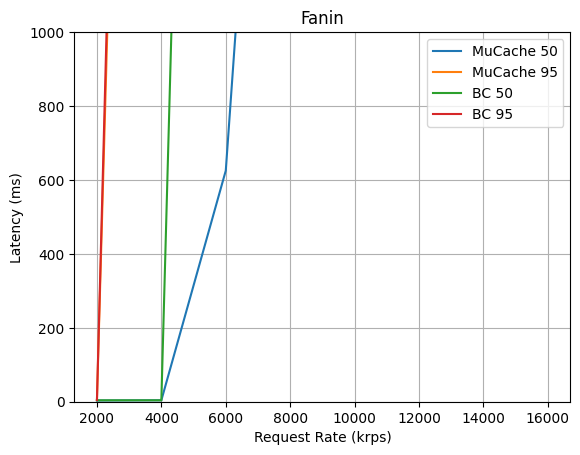

In [89]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
# App 2000mi 2Gi
# Cache 1500mi 2Gi
# Redis 1500mi 2Gi
# CM 2000mi 3Gi
x, bc_out = getStats( "fanin-baseline-3000app-120oha.json" )
_, mucache_out = getStats( "fanin-3000app-120oha.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin", False, ylim = 1000 )

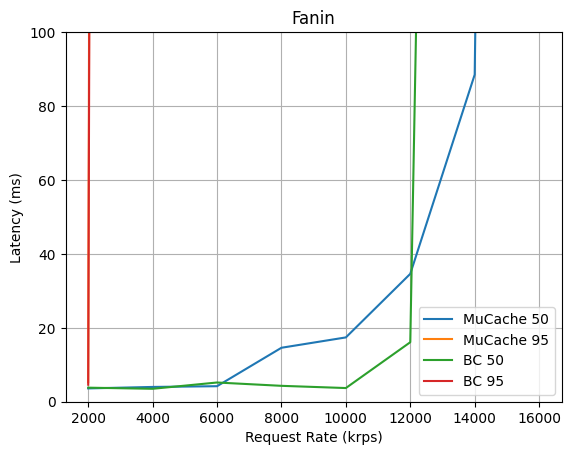

In [91]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
# App 2000mi 2Gi
# Cache 1500mi 2Gi
# Redis 1500mi 2Gi
# CM 2000mi 3Gi
x, bc_out = getStats( "fanin-baseline-fixedapp.json" )
_, mucache_out = getStats( "fanin-fixedapp.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin", False, ylim = 100 )

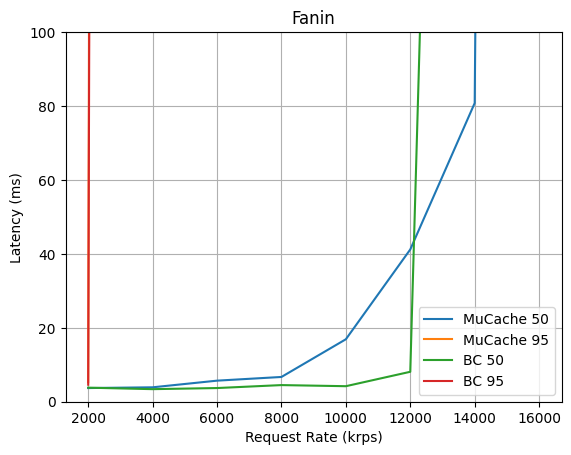

In [92]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
# App 2000mi 2Gi
# Cache 1500mi 2Gi
# Redis 1500mi 2Gi
# CM 2000mi 3Gi
x, bc_out = getStats( "fanin-baseline-fixedapp-2.json" )
_, mucache_out = getStats( "fanin-fixedapp-2.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin", False, ylim = 100 )

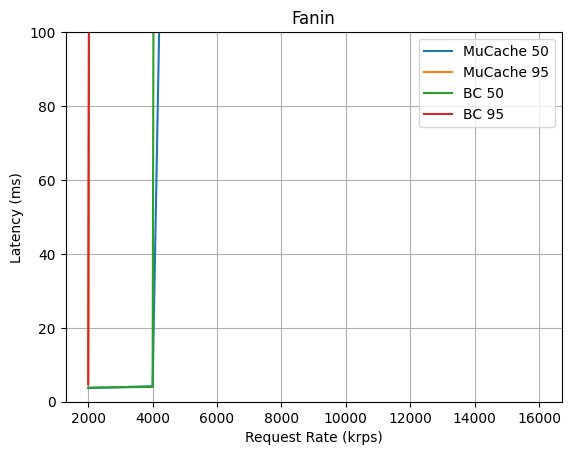

In [96]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
# App 2000mi 2Gi
# Cache 1500mi 2Gi
# Redis 1500mi 2Gi
# CM 2000mi 3Gi
x, bc_out = getStats( "fanin-baseline-fixedapp-120oha.json" )
_, mucache_out = getStats( "fanin-fixedapp-120oha.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin", False, ylim=100)

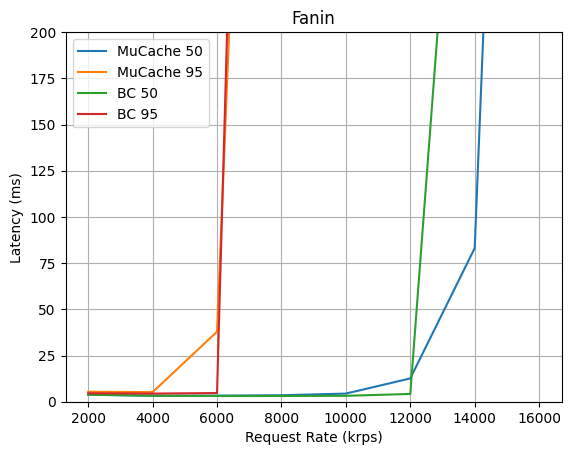

In [99]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
# App 2000mi 2Gi
# Cache 1500mi 2Gi
# Redis 1500mi 2Gi
# CM 2000mi 3Gi
x, bc_out = getStats( "fanin-baseline-12proxyworkers.json" )
_, mucache_out = getStats( "fanin-12proxyworkers.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin", False, ylim = 200 )

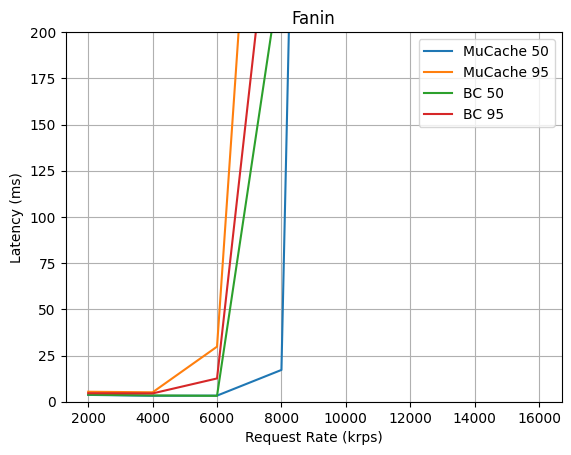

In [101]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
# App 2000mi 2Gi
# Cache 1500mi 2Gi
# Redis 1500mi 2Gi
# CM 2000mi 3Gi
x, bc_out = getStats( "fanin-baseline-12proxyworkers-1000app.json" )
_, mucache_out = getStats( "fanin-12proxyworkers-1000app.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin", False, ylim = 200 )

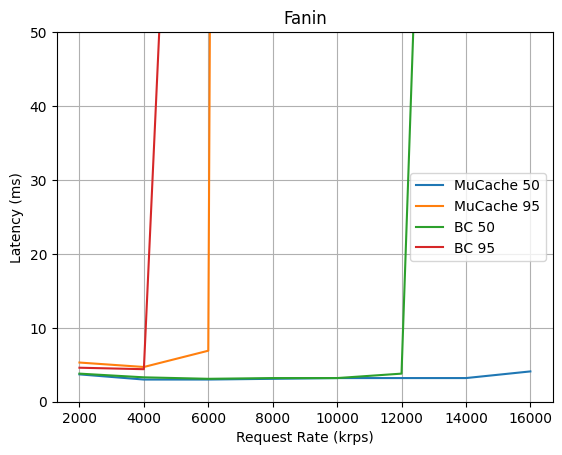

In [133]:
# Chain but increased resources for both redis and cache for 1hop and 4 procs
# Significant boost to both redis and cache
# App 2000mi 2Gi
# Cache 1500mi 2Gi
# Redis 1500mi 2Gi
# CM 2000mi 3Gi
x, bc_out = getStats( "fanin-baseline-5000app-12proxyworkers-4zmq.json" )
_, mucache_out = getStats( "fanin-5000app-12proxyworkers-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin", False, ylim = 50 )

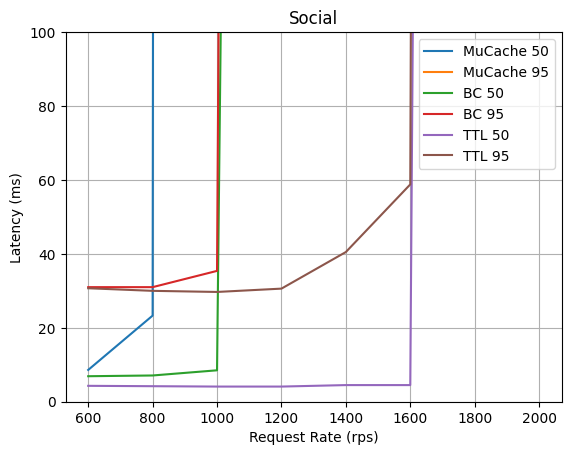

In [21]:
# Social with resources
x, bc_out = getStats( "social-baseline-new.json" )
_, mucache_out = getStats( "social-new.json" )
_, ttl_out = getStats( "social-upper-new.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Social", ylim=100 )

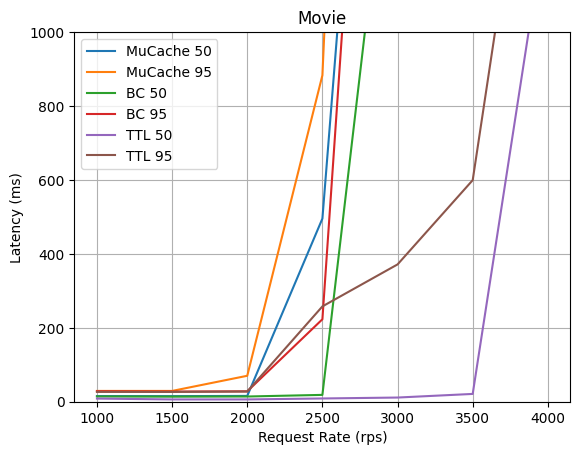

In [23]:
# Movie with resources
x, bc_out = getStats( "movie-baseline-new.json" )
_, mucache_out = getStats( "movie-new.json" )
_, ttl_out = getStats( "movie-upper-new.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Movie", ylim=1000 )

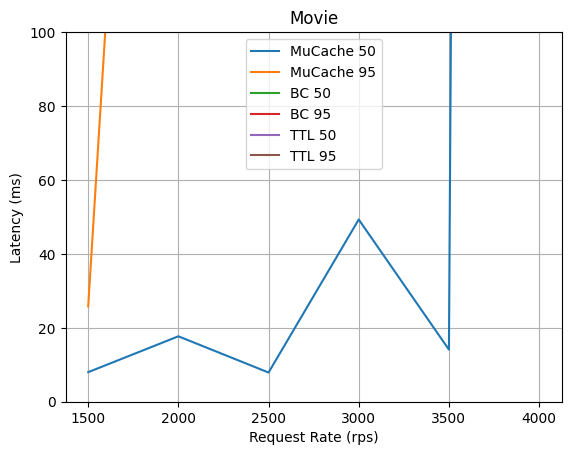

In [109]:
# Movie with resources
x, bc_out = getStats( "movie-baseline-12proxy.json" )
_, mucache_out = getStats( "movie-12proxy-4zmq.json" )
_, ttl_out = getStats( "movie-upper-12proxy.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"][1:]],
         ["BC 95", bc_out["95"][1:]],
         ["TTL 50", ttl_out["50"][1:]],
         ["TTL 95", ttl_out["95"][1:]]]

plotStats( x[1:], plots, "Request Rate (rps)", "Latency (ms)", "Movie", ylim = 100 )

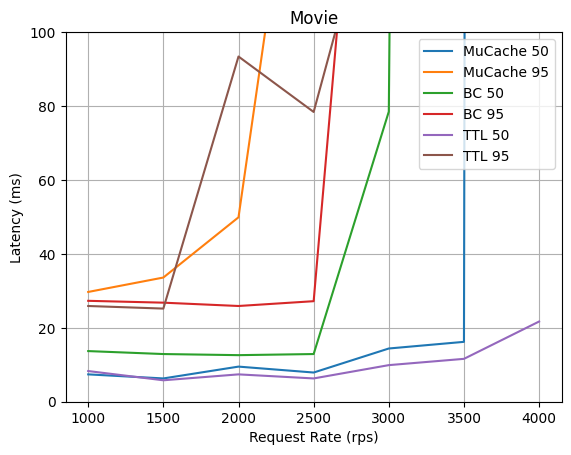

In [112]:
# Movie with resources
x, bc_out = getStats( "movie-baseline-5000app-12proxy-4zmq.json" )
_, mucache_out = getStats( "movie-5000app-12proxy-4zmq.json" )
_, ttl_out = getStats( "movie-upper-5000app-12proxy-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Movie", ylim = 100 )

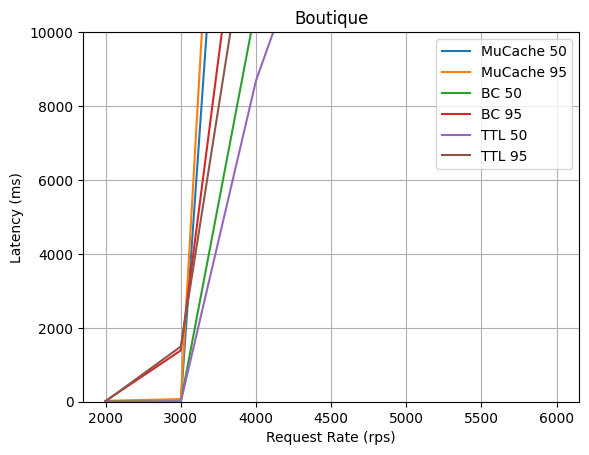

In [28]:
# Boutique with resources
x, bc_out = getStats( "boutique-baseline-new.json" )
_, mucache_out = getStats( "boutique-new.json" )
_, ttl_out = getStats( "boutique-upper-new.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim=10000 )

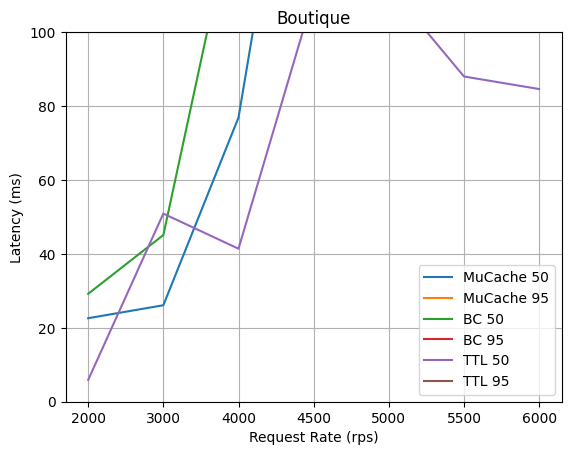

In [41]:
# Boutique with resources
x, bc_out = getStats( "boutique-baseline-revert.json" )
_, mucache_out = getStats( "boutique-revert.json" )
_, ttl_out = getStats( "boutique-upper-revert.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim=100 )

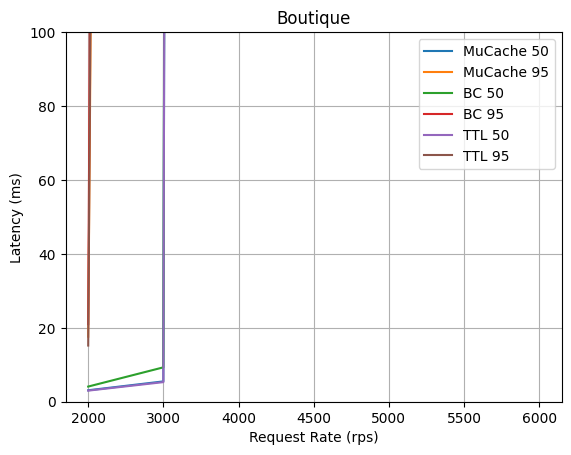

In [44]:
# Boutique with resources
x, bc_out = getStats( "boutique-baseline-revert-2.json" )
_, mucache_out = getStats( "boutique-revert-2.json" )
_, ttl_out = getStats( "boutique-upper-revert-2.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim = 100 )

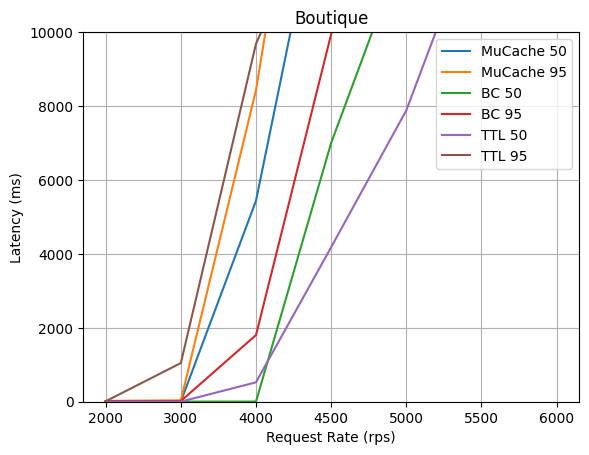

In [30]:
# Boutique with resources
x, bc_out = getStats( "boutique-baseline-double-mem-TTL-half-items.json" )
_, mucache_out = getStats( "boutique-double-mem-TTL-half-items.json" )
_, ttl_out = getStats( "boutique-upper-double-mem-TTL-half-items.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim=10000 )

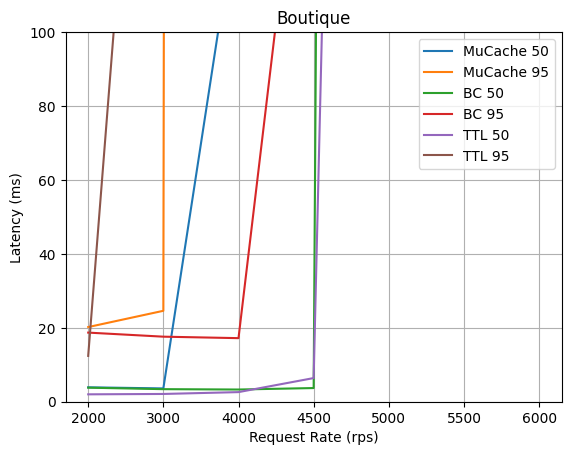

In [32]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-quad-mem-TTL-quad-items.json" )
_, mucache_out = getStats( "boutique-quad-mem-TTL-quad-items.json" )
_, ttl_out = getStats( "boutique-upper-quad-mem-TTL-quad-items.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim=100 )

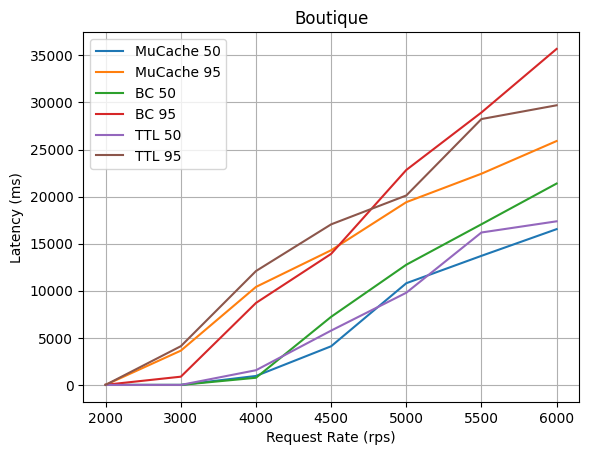

In [47]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-revert-1000size-5productsize-40-cache-size.json" )
_, mucache_out = getStats( "boutique-revert-1000size-5productsize-40-cache-size.json" )
_, ttl_out = getStats( "boutique-upper-revert-1000size-5productsize-40-cache-size.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", )

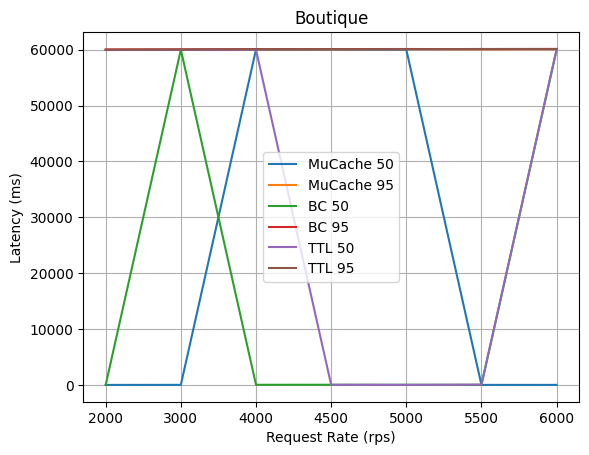

In [48]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-revert-10size-5productsize-40-cache-size.json" )
_, mucache_out = getStats( "boutique-revert-10size-5productsize-40-cache-size.json" )
_, ttl_out = getStats( "boutique-upper-revert-10size-5productsize-40-cache-size.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", )

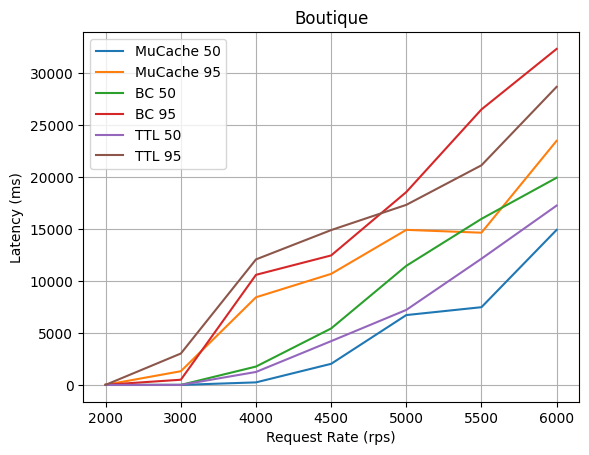

In [52]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-revert-10000size-5productsize-80-cache-size.json" )
_, mucache_out = getStats( "boutique-revert-10000size-5productsize-80-cache-size.json" )
_, ttl_out = getStats( "boutique-upper-revert-10000size-5productsize-80-cache-size.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", )

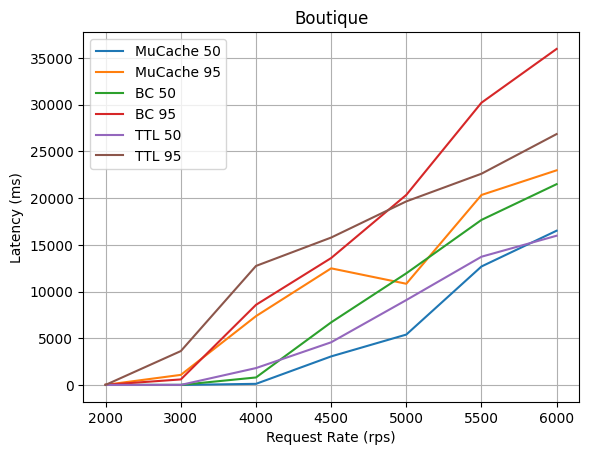

In [55]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-revert-10000size-10productsize-80-cache-size-4zmq.json" )
_, mucache_out = getStats( "boutique-revert-10000size-10productsize-80-cache-size-4zmq.json" )
_, ttl_out = getStats( "boutique-upper-revert-10000size-10productsize-80-cache-size-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", )

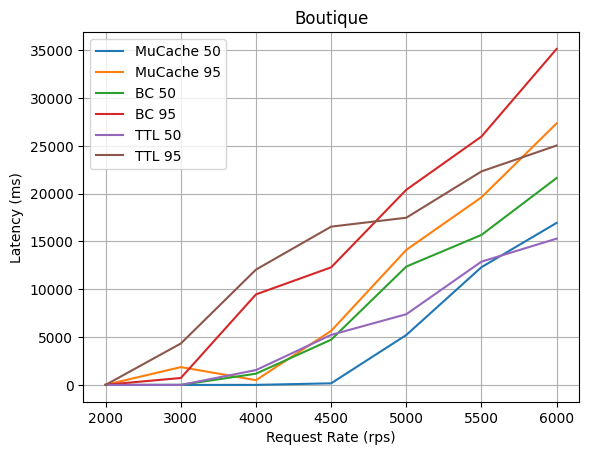

In [58]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-revert-10000size-1productsize-80-cache-size-4zmq.json" )
_, mucache_out = getStats( "boutique-revert-10000size-1productsize-80-cache-size-4zmq.json" )
_, ttl_out = getStats( "boutique-upper-revert-10000size-1productsize-80-cache-size-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique",
         )

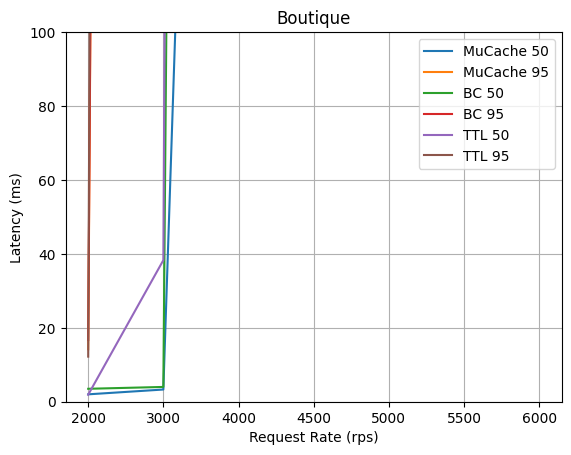

In [60]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-revert-100size-1productsize-80-cache-size-4zmq.json" )
_, mucache_out = getStats( "boutique-revert-100size-1productsize-80-cache-size-4zmq.json" )
_, ttl_out = getStats( "boutique-upper-revert-100size-1productsize-80-cache-size-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique",ylim=100)

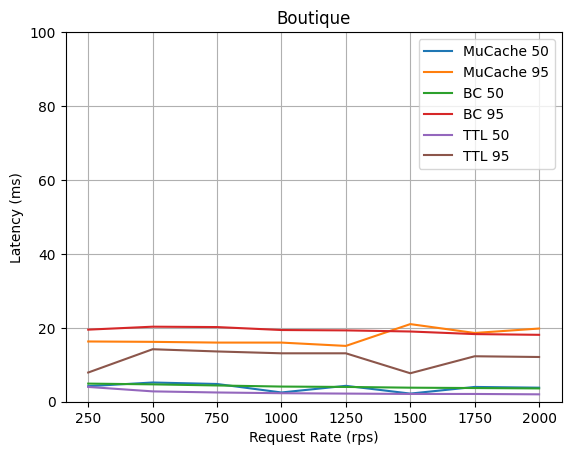

In [61]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-revert-10000size-10productsize-80-cache-size-4zmq-250-2000RPS.json" )
_, mucache_out = getStats( "boutique-revert-10000size-10productsize-80-cache-size-4zmq-250-2000RPS.json" )
_, ttl_out = getStats( "boutique-upper-revert-10000size-10productsize-80-cache-size-4zmq-250-2000RPS.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique",ylim=100)

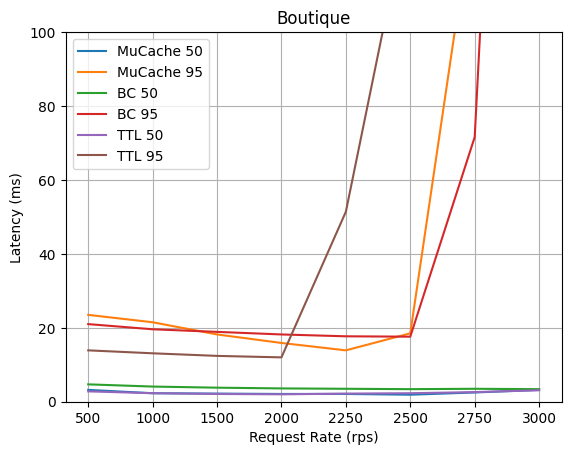

In [62]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-revert-10000size-10productsize-80-cache-size-4zmq-500-3000RPS.json" )
_, mucache_out = getStats( "boutique-revert-10000size-10productsize-80-cache-size-4zmq-500-3000RPS.json" )
_, ttl_out = getStats( "boutique-upper-revert-10000size-10productsize-80-cache-size-4zmq-500-3000RPS.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique",ylim=100)

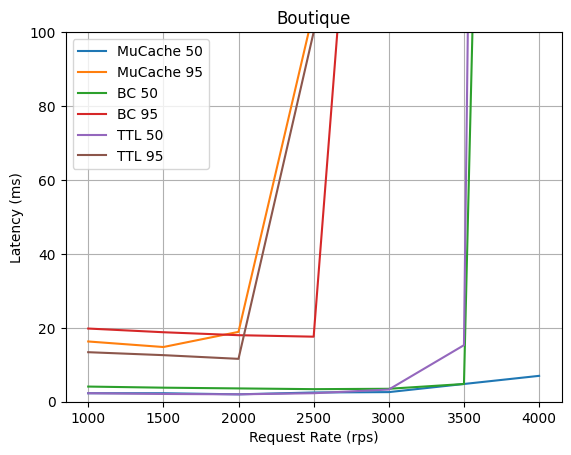

In [64]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-revert-10000size-10productsize-80-cache-size-4zmq-500-4000RPS.json" )
_, mucache_out = getStats( "boutique-revert-10000size-10productsize-80-cache-size-4zmq-500-4000RPS.json" )
_, ttl_out = getStats( "boutique-upper-revert-10000size-10productsize-80-cache-size-4zmq-500-4000RPS.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique",ylim=100)

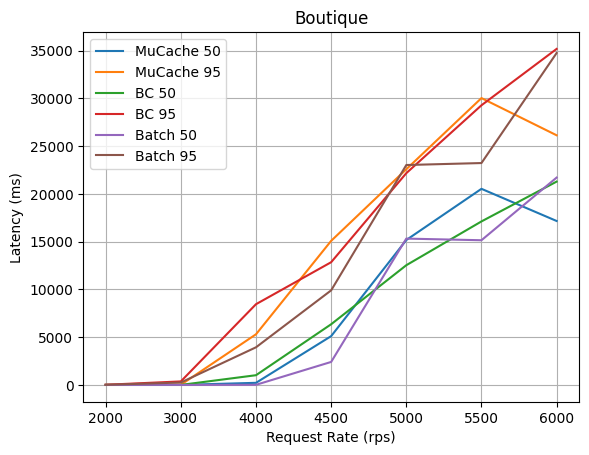

In [71]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-batch.json" )
_, mucache_out = getStats( "boutique-normal-batch.json" )
_, batch_out = getStats( "boutique-batch.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique")

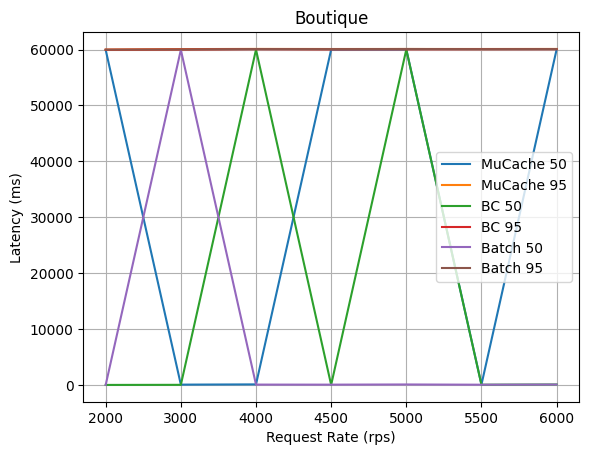

In [73]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-10size-1productsize.json" )
_, mucache_out = getStats( "boutique-10size-1productsize.json" )
_, batch_out = getStats( "boutique-batch-10size-1productsize.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique")

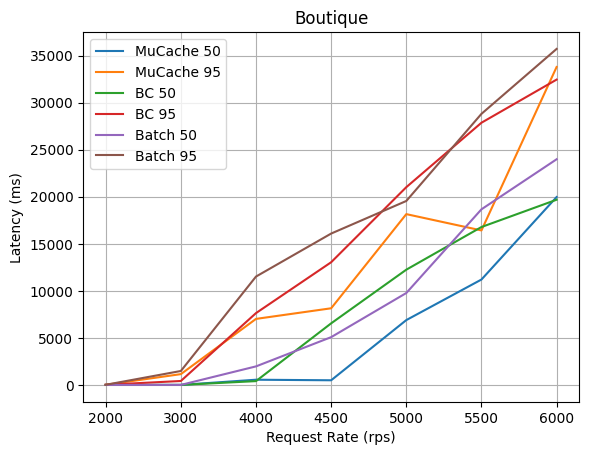

In [74]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-100size-1productsize.json" )
_, mucache_out = getStats( "boutique-100size-1productsize.json" )
_, batch_out = getStats( "boutique-batch-100size-1productsize.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique")

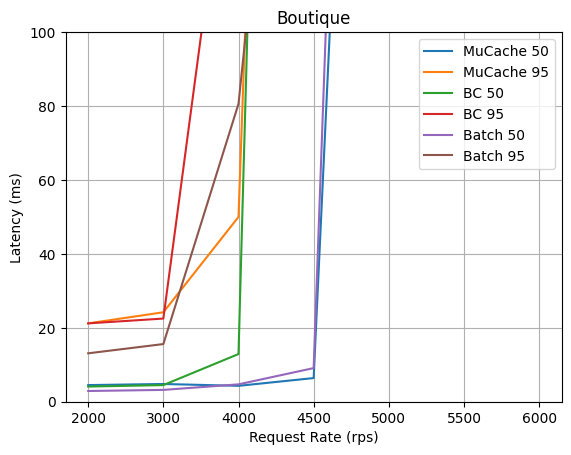

In [124]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-originalSize-5000app-12proxy-4zmq.json" )
_, mucache_out = getStats( "boutique-originalSize-5000app-12proxy-4zmq.json" )
_, batch_out = getStats( "boutique-upper-originalSize-5000app-12proxy-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim = 100)

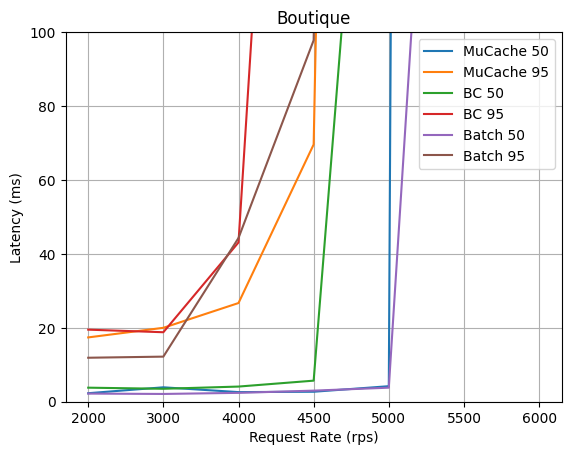

In [126]:
# Boutique with resources
# Some bottle neck somewhere?
x, bc_out = getStats( "boutique-baseline-halfSize-5000app-12proxy-4zmq.json" )
_, mucache_out = getStats( "boutique-halfSize-5000app-12proxy-4zmq.json" )
_, batch_out = getStats( "boutique-upper-halfSize-5000app-12proxy-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim = 100)

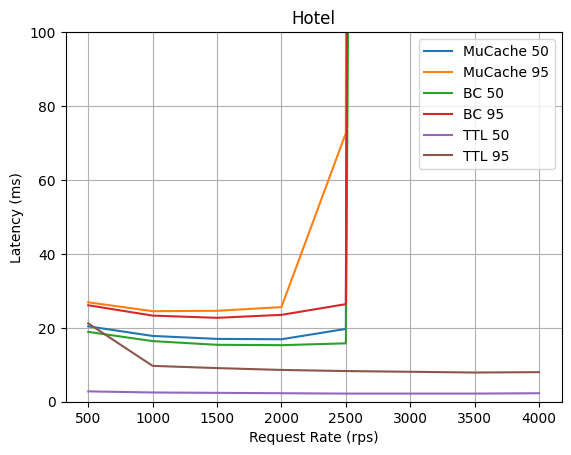

In [29]:
# Boutique with resources
x, bc_out = getStats( "hotel-baseline-new.json" )
_, mucache_out = getStats( "hotel-new.json" )
_, ttl_out = getStats( "hotel-upper-new.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Hotel", ylim = 100 )

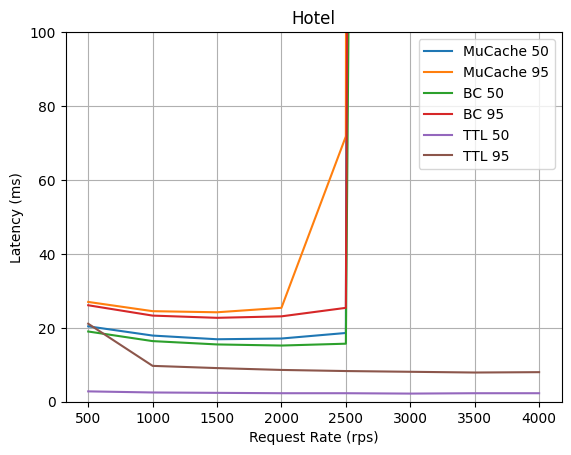

In [33]:
# Boutique with resources
x, bc_out = getStats( "hotel-baseline-quad-mem.json" )
_, mucache_out = getStats( "hotel-quad-mem.json" )
_, ttl_out = getStats( "hotel-upper-quad-mem.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Hotel", ylim = 100 )

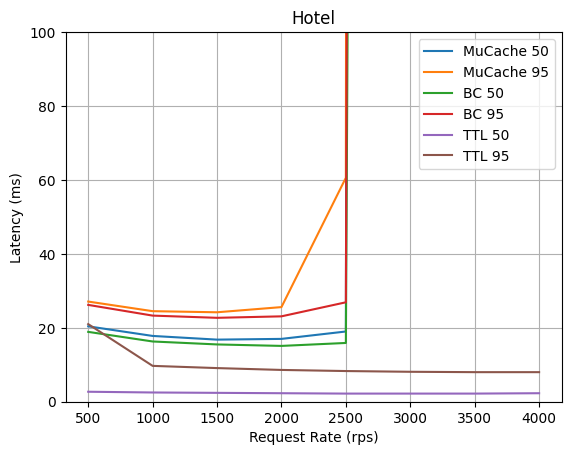

In [34]:
# Boutique with resources
x, bc_out = getStats( "hotel-baseline-2.5appCPU-2cacheCPU.json" )
_, mucache_out = getStats( "hotel-2.5appCPU-2cacheCPU.json" )
_, ttl_out = getStats( "hotel-upper-2.5appCPU-2cacheCPU.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Hotel", ylim = 100 )

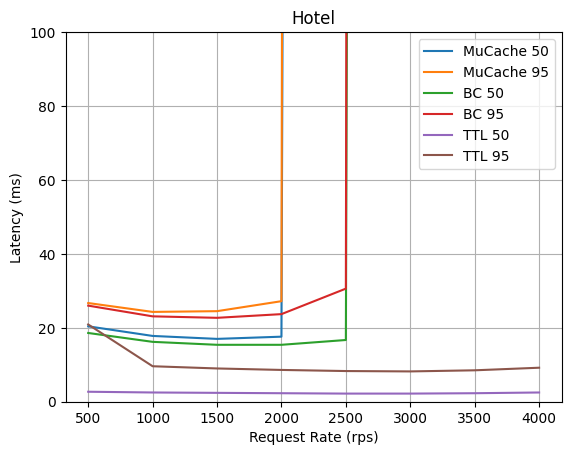

In [35]:
# Boutique with resources
x, bc_out = getStats( "hotel-baseline-2.5appCPU-2cacheCPU-4proc.json" )
_, mucache_out = getStats( "hotel-2.5appCPU-2cacheCPU-4proc.json" )
_, ttl_out = getStats( "hotel-upper-2.5appCPU-2cacheCPU-4proc.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Hotel", ylim = 100 )

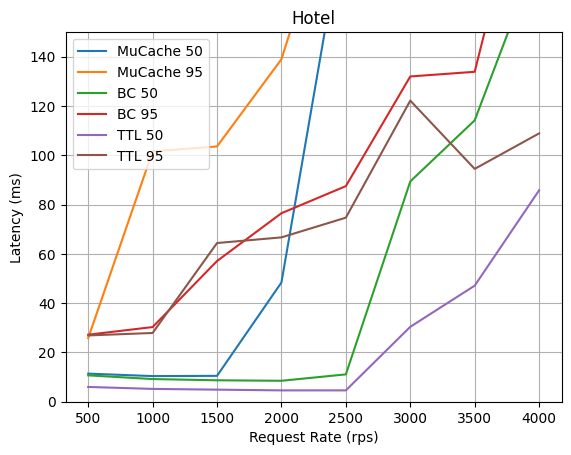

In [40]:
# Boutique with resources
x, bc_out = getStats( "hotel-baseline-small-hotel-size.json" )
_, mucache_out = getStats( "hotel-small-hotel-size.json" )
_, ttl_out = getStats( "hotel-upper-small-hotel-size.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Hotel", ylim = 150 )

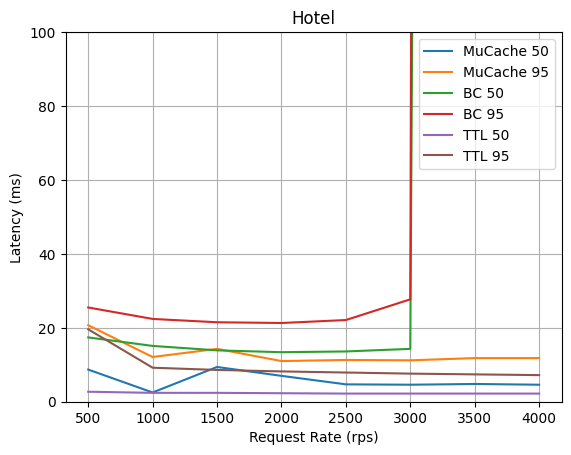

In [117]:
# Boutique with resources
x, bc_out = getStats( "hotel-baseline-5000app-12proxy-4zmq.json" )
_, mucache_out = getStats( "hotel-5000app-12proxy-4zmq.json" )
_, ttl_out = getStats( "hotel-upper-5000app-12proxy-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Hotel", ylim = 100 )

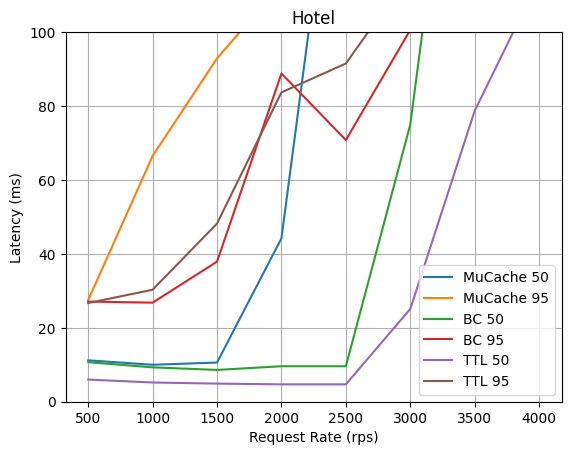

In [37]:
# Boutique with resources
x, bc_out = getStats( "hotel-baseline-more-app-resources.json" )
_, mucache_out = getStats( "hotel-more-app-resources.json" )
_, ttl_out = getStats( "hotel-upper-more-app-resources.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Hotel", ylim = 100 )

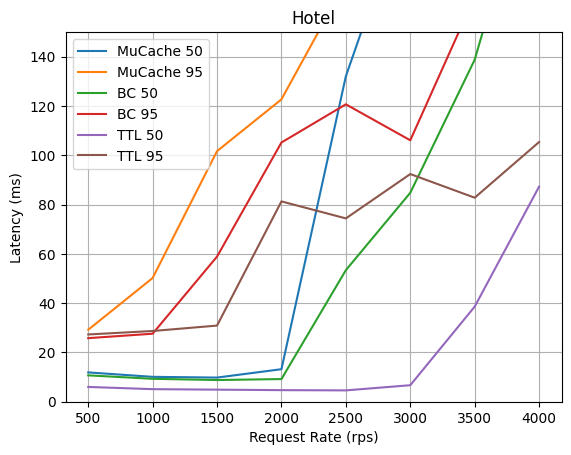

In [41]:
# Boutique with resources
x, bc_out = getStats( "hotel-baseline-more-cm-resources.json" )
_, mucache_out = getStats( "hotel-more-cm-resources.json" )
_, ttl_out = getStats( "hotel-upper-more-cm-resources.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Hotel", ylim = 150 )

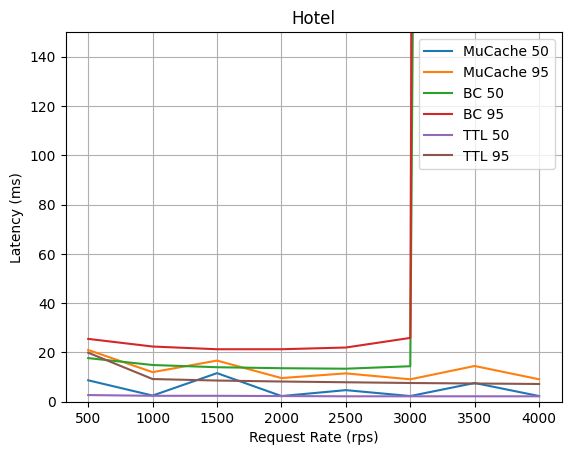

In [120]:
# Boutique with resources
x, bc_out = getStats( "hotel-baseline-5000app-12proxy-4zmq-hotelsize50.json" )
_, mucache_out = getStats( "hotel-5000app-12proxy-4zmq-hotelsize50.json" )
_, ttl_out = getStats( "hotel-upper-5000app-12proxy-4zmq-hotelsize50.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Hotel", ylim = 150 )

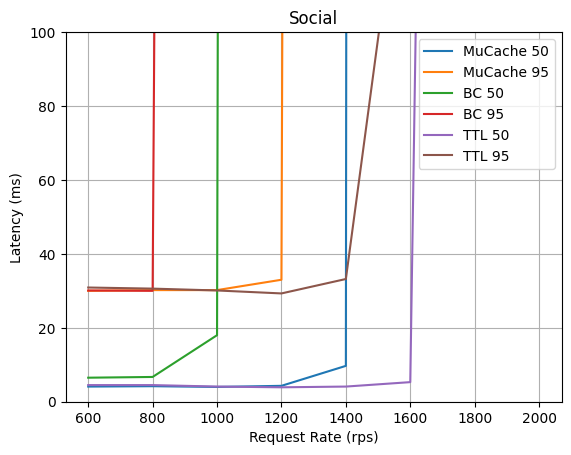

In [118]:
# Boutique with resources
x, bc_out = getStats( "social-baseline-5000app-12proxy-4zmq.json" )
_, mucache_out = getStats( "social-5000app-12proxy-4zmq.json" )
_, ttl_out = getStats( "social-upper-5000app-12proxy-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Social", ylim = 100 )